In [ ]:
import os
import tarfile
import urllib.request
import pandas as pd

DOWNLOAD_ROOT = "https://github.com/ageron/data/raw/main/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)

fetch_housing_data()
df = pd.read_csv(os.path.join(HOUSING_PATH, "housing.csv"))

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [54]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [55]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [56]:
df.isna().sum()
# df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [57]:
df.dtypes.value_counts()

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cate_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical features:", num_features, "\nCategorical features:", cate_features)

Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value'] 
Categorical features: ['ocean_proximity']


In [58]:
# df.drop(columns=['total_bedrooms'], inplace=True)

# df.dropna(subset=['total_bedrooms'], inplace=True)


df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
# df.isna().sum()

In [ ]:
def missing_report(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    report = pd.DataFrame({
        'column': missing_count.index,
        'missing_count': missing_count.values,
        'missing_percent': missing_percent.values.round(2)
    })

    report = report[report['missing_count'] > 0]  
    report = report.sort_values(by='missing_count', ascending=False).reset_index(drop=True)
    
    return report

df1 = missing_report(df)
df1


,column,missing_count,missing_percent
0,total_bedrooms,207,1.0


In [4]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], prefix='ocean').astype(int)
df_encoded.head()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [66]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop=None)  

encoded_array = encoder.fit_transform(df[['ocean_proximity']])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['ocean_proximity'])
)

df_encoded = pd.concat([df.drop('ocean_proximity', axis=1), encoded_df], axis=1)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


In [67]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

num_features = ['median_income', 'housing_median_age', 'population', 'median_house_value']

data = df[num_features]

std_scaler = StandardScaler()
data_std_scaled = std_scaler.fit_transform(data)

minmax_scaler = MinMaxScaler()
data_minmax_scaled = minmax_scaler.fit_transform(data)

df_std_scaled = pd.DataFrame(data_std_scaled, columns=num_features)
df_minmax_scaled = pd.DataFrame(data_minmax_scaled, columns=num_features)

print("Standard Scaled Data:")
print(df_std_scaled.head())

print("\nMinMax Scaled Data:")
print(df_minmax_scaled.head())


Standard Scaled Data:
   median_income  housing_median_age  population  median_house_value
0       2.344766            0.982143   -0.974429            2.129631
1       2.332238           -0.607019    0.861439            1.314156
2       1.782699            1.856182   -0.820777            1.258693
3       0.932968            1.856182   -0.766028            1.165100
4      -0.012881            1.856182   -0.759847            1.172900

MinMax Scaled Data:
   median_income  housing_median_age  population  median_house_value
0       0.539668            0.784314    0.008941            0.902266
1       0.538027            0.392157    0.067210            0.708247
2       0.466028            1.000000    0.013818            0.695051
3       0.354699            1.000000    0.015555            0.672783
4       0.230776            1.000000    0.015752            0.674638


In [68]:

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())


   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467


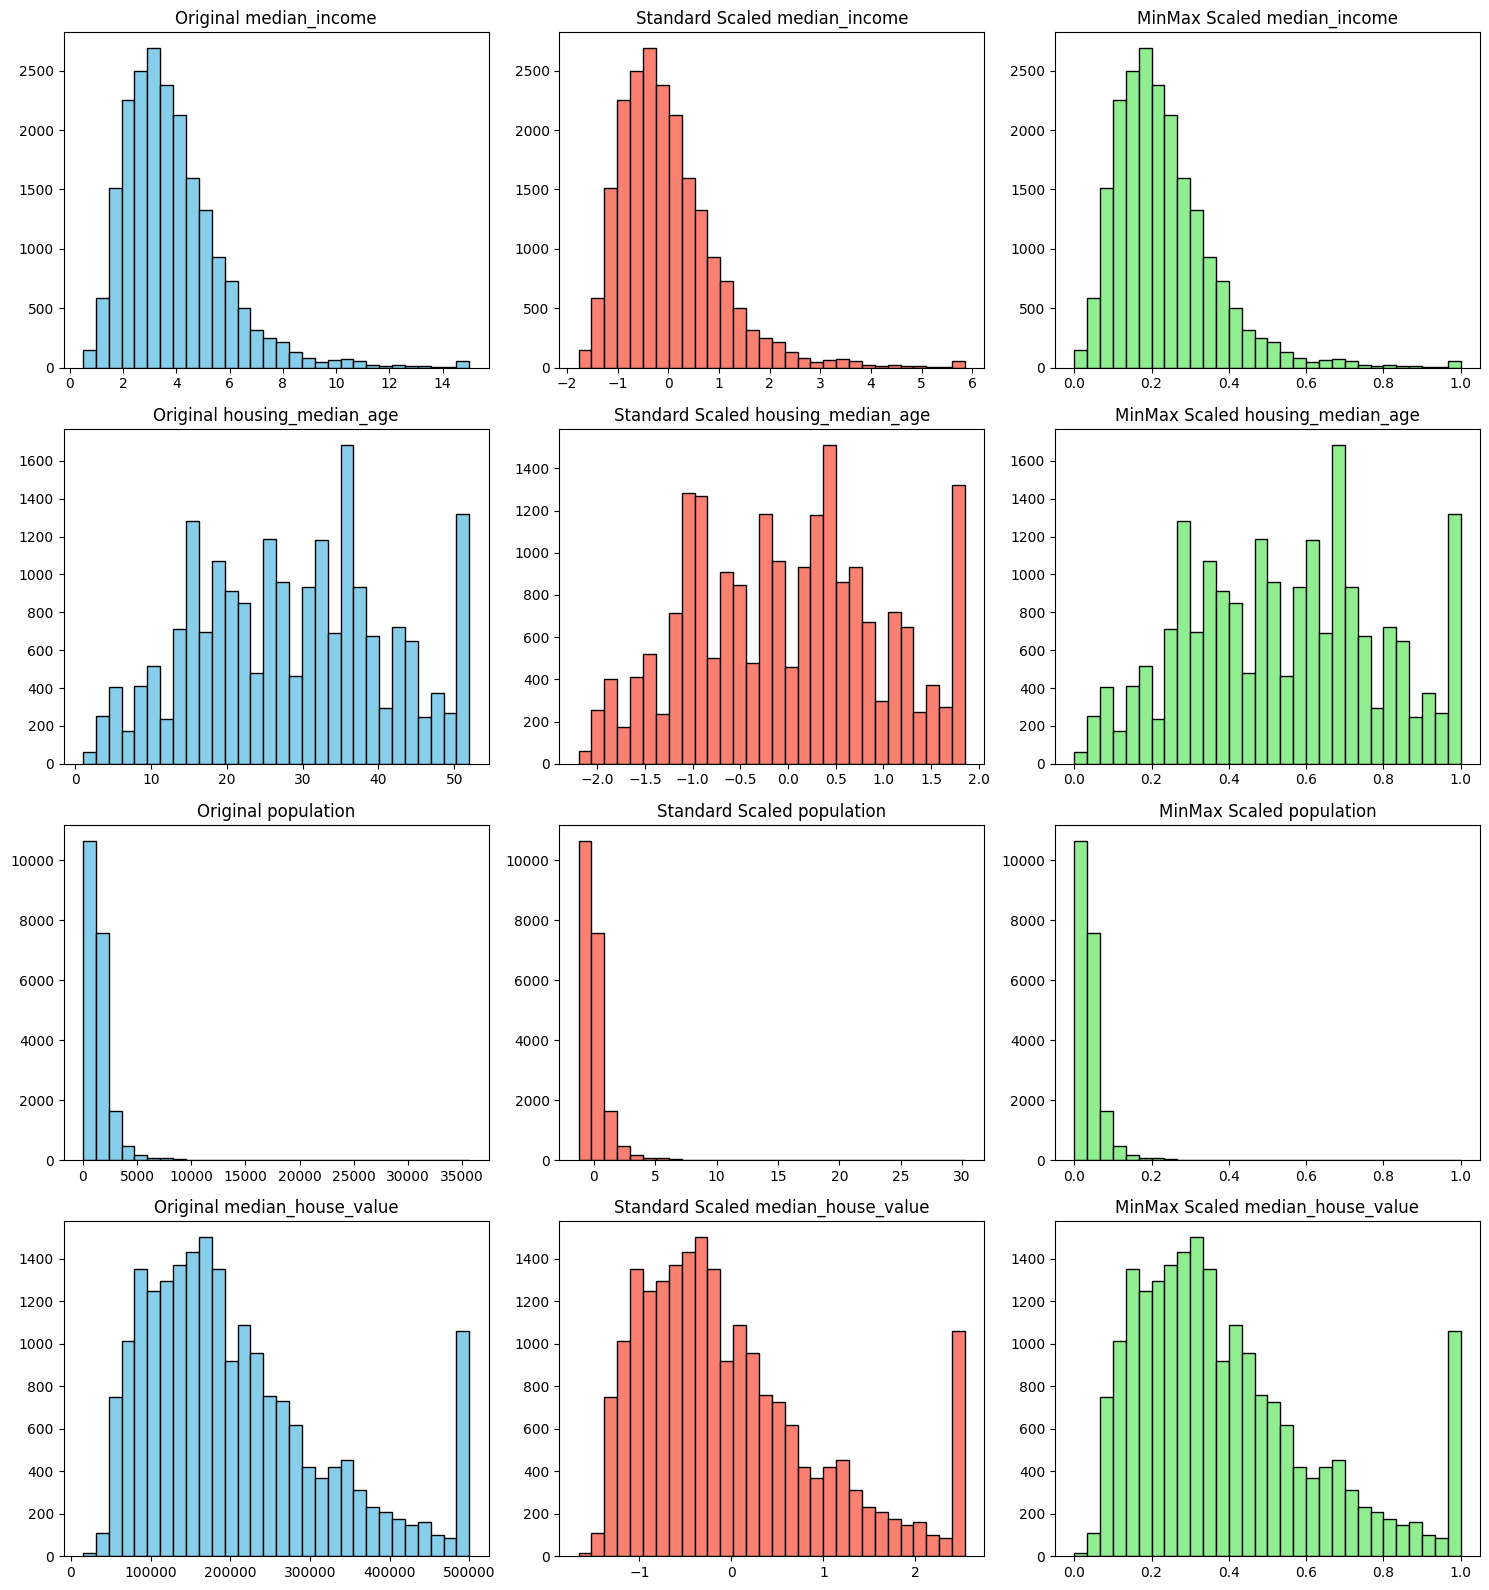

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sample numerical columns to scale
num_features = ['median_income', 'housing_median_age', 'population', 'median_house_value']

# Original data
data = df[num_features]

# Initialize scalers
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply StandardScaler
data_std_scaled = pd.DataFrame(std_scaler.fit_transform(data), columns=num_features)

# Apply MinMaxScaler
data_minmax_scaled = pd.DataFrame(minmax_scaler.fit_transform(data), columns=num_features)

# Plot histograms
fig, axes = plt.subplots(len(num_features), 3, figsize=(15, 4 * len(num_features)))

for i, feature in enumerate(num_features):
    # Original
    axes[i, 0].hist(df[feature], bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Original {feature}')
    
    # StandardScaler
    axes[i, 1].hist(data_std_scaled[feature], bins=30, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f'Standard Scaled {feature}')
    
    # MinMaxScaler
    axes[i, 2].hist(data_minmax_scaled[feature], bins=30, color='lightgreen', edgecolor='black')
    axes[i, 2].set_title(f'MinMax Scaled {feature}')
    
plt.tight_layout()
plt.show()

